# 03. Superstore Exploratory Data Analysis & Business Intelligence
This notebook analyzes the **US Retail Superstore Dataset** (`Sample - Superstore.csv`) to uncover profitability trends, product category dynamics, regional performance, and discount impact on margins.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
print(f"Dataset shape: {df.shape}")
df.head()


In [ ]:
# Check column data types and nulls
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


In [ ]:
# Convert Order Date & Ship Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Order Month"] = df["Order Date"].dt.to_period("M")
df["Profit Margin (%)"] = (df["Profit"] / df["Sales"]) * 100

print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {(df['Profit'].sum() / df['Sales'].sum()) * 100:.2f}%")


### 1. Sales & Profit Breakdown by Category & Sub-Category

In [ ]:
category_summary = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
}).reset_index()

category_summary["Profit Margin (%)"] = (category_summary["Profit"] / category_summary["Sales"]) * 100
display(category_summary.round(2))

# Plot Sales vs Profit by Category
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
category_summary.plot(x="Category", y="Sales", kind="bar", ax=ax[0], color="royalblue", legend=False)
ax[0].set_title("Total Sales by Category ($)")
ax[0].set_ylabel("Sales ($)")

category_summary.plot(x="Category", y="Profit", kind="bar", ax=ax[1], color="forestgreen", legend=False)
ax[1].set_title("Total Profit by Category ($)")
ax[1].set_ylabel("Profit ($)")
plt.tight_layout()
plt.show()


### 2. Regional Sales & Profitability Analysis

In [ ]:
region_summary = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

fig = px.bar(
    region_summary,
    x="Region",
    y=["Sales", "Profit"],
    barmode="group",
    title="Sales vs Profit Across US Regions",
    color_discrete_map={"Sales": "#2563EB", "Profit": "#10B981"}
)
fig.show()


### 3. Impact of Discounts on Profitability

In [ ]:
plt.figure(figsize=(10, 5))
discount_profit = df.groupby("Discount")["Profit"].mean()
discount_profit.plot(kind="line", marker="o", color="crimson", linewidth=2)
plt.title("Average Profit vs. Discount Level")
plt.xlabel("Discount Rate (0.0 to 0.8)")
plt.ylabel("Average Profit per Order ($)")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


### 4. Sub-Category Loss Leaders vs. High-Margin Winners

In [ ]:
subcat_summary = df.groupby("Sub-Category")["Profit"].sum().sort_values().reset_index()

plt.figure(figsize=(12, 6))
colors = ["red" if p < 0 else "green" for p in subcat_summary["Profit"]]
plt.barh(subcat_summary["Sub-Category"], subcat_summary["Profit"], color=colors)
plt.title("Total Profit / Loss by Sub-Category")
plt.xlabel("Total Profit ($)")
plt.axvline(0, color="black", linestyle="--")
plt.tight_layout()
plt.show()


Accuracy Score:  93.35%
F1-Score:        0.9588
Precision:       0.9579
Recall:          0.9597

--- Classification Report ---
                     precision    recall  f1-score   support

Loss / Unprofitable       0.83      0.82      0.83       387
         Profitable       0.96      0.96      0.96      1612

           accuracy                           0.93      1999
          macro avg       0.89      0.89      0.89      1999
       weighted avg       0.93      0.93      0.93      1999



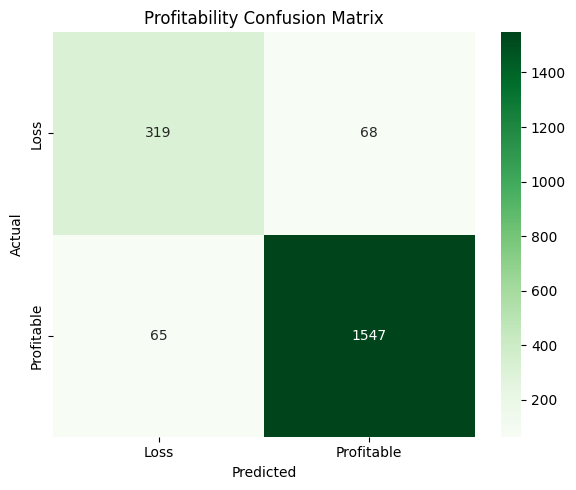

In [1]:
# ==============================================================================
# SUPERSTORE PROFITABILITY PREDICTION & EVALUATION
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Load Superstore Data
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

# Create Target: 1 = Profitable, 0 = Unprofitable / Loss
df["Is_Profitable"] = (df["Profit"] > 0).astype(int)

# Features: Sales, Quantity, Discount
X = df[["Sales", "Quantity", "Discount"]]
y = df["Is_Profitable"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy Score:  {acc * 100:.2f}%")
print(f"F1-Score:        {f1:.4f}")
print(f"Precision:       {prec:.4f}")
print(f"Recall:          {rec:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Loss / Unprofitable", "Profitable"]))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Loss", "Profitable"], yticklabels=["Loss", "Profitable"])
plt.title("Profitability Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()